# Worst case default rate

In [19]:
# !pip install -U openpyxl

import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from math import log

from scipy.optimize import minimize


# calculate Worst case

In [20]:
def WCDR(default_prob, corr, prob):
    """
    Vasicek model
    return the x% prob worst case one-year default rate
    default_prob = one-year probabilty of default for each loan
    corr = copula correlation on the year-by-year default distribution
    prob = x% worst case probability
    """
    return norm.cdf((norm.ppf(default_prob) + np.sqrt(corr) * norm.ppf(prob))/np.sqrt(1 - corr))

WCDR(.02, .10, .999),WCDR(.02, .10, .001)

(np.float64(0.12823710729942317), np.float64(0.0006993507698993767))

# annual percentage default rates for all rated companies
chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://www.maalot.co.il/Publications/TS20220424121828.PDF

https://www.spglobal.com/ratings/en/research/articles/230425-default-transition-and-recovery-2022-annual-global-corporate-default-and-rating-transition-study-12702145

## list of defaults in 2023:
https://www.spglobal.com/ratings/en/research/articles/231020-default-transition-and-recovery-distressed-exchanges-drive-2023-global-corporate-defaults-to-118-12886902

In [21]:
display(default_rate := pd.read_excel("data/SP_annual_default_rates.xlsx"))

,Year,Total defaults,Investment-grade defaults,Speculative-grade defaults,Default rate (%),Investment-grade default rate(%),Speculative-grade default rate (%),Total debt outstanding (bil. $)
0,1981,2,0,2,0.15,0.00,0.63,0.06
1,1982,18,2,15,1.22,0.19,4.46,0.90
2,1983,12,1,10,0.77,0.09,2.98,0.37
3,1984,14,2,12,0.93,0.17,3.31,0.36
4,1985,19,0,18,1.13,0.00,4.37,0.31
5,1986,34,2,30,1.74,0.15,5.75,0.46
6,1987,19,0,19,0.95,0.00,2.83,1.60
7,1988,32,0,29,1.39,0.00,3.88,3.30
8,1989,44,3,35,1.79,0.22,4.70,7.28
9,1990,70,2,56,2.74,0.14,8.12,21.15


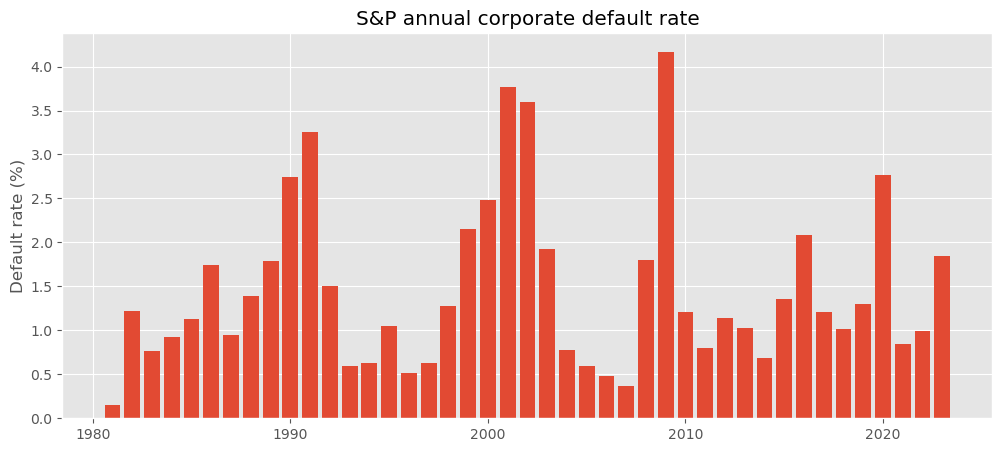

In [22]:
plt.style.use('ggplot')
plt.figure(figsize=(12,5))
plt.bar(default_rate['Year'], default_rate['Default rate (%)'])
plt.title('S&P annual corporate default rate')
plt.ylabel('Default rate (%)')
plt.show()

# WCDR distribution function
$$G(DR) = N\left(\frac{\sqrt{1-\rho}N^{-1}(DR) -N^{-1}(PD)}{\sqrt{\rho}}\right)$$

# differentiate to create the density function (likelihood)

highest likelihood:
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -140.33697259634272
        x: [ 1.463e-02  6.230e-02]
      nit: 13
      jac: [-1.043e-03  3.433e-03]
     nfev: 54
     njev: 18
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>


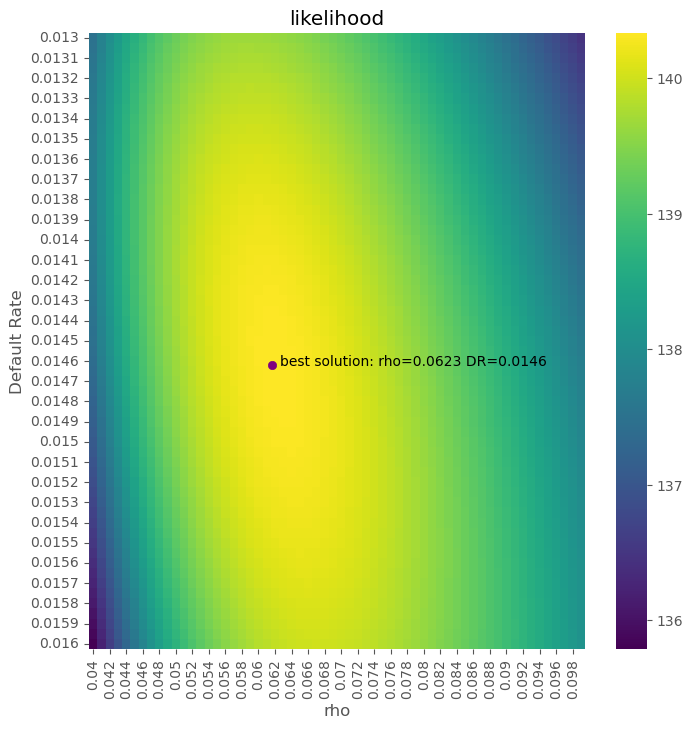

CPU times: total: 1min 46s
Wall time: 1min 59s


In [23]:
%%time

class WCDR_density():
    def __init__(self, default_history):
        """ get the history of default rates """
        self.default_history = default_history
    
    def compute_likelihood(self, DR):
        """ for the G(DR) cumulative probability density function for the Default Rate"""
        try:
            return np.sqrt((1-self.rho) / self.rho) * np.exp(0.5 * (pow(norm.ppf(DR),2) - pow((np.sqrt(1-self.rho) * norm.ppf(DR) - norm.ppf(self.PD))/np.sqrt(self.rho),2)))
        except:
            print(f"error in calculating sqrt for {DR = }, {self.rho = }")
            return 0.0
    
    def calc(self, PD, rho):
        """ sum of the likelihoods for the historical default rates for a probability of default (PD) and year-to-year dfault correlation (rho) """
        self.PD = PD
        self.rho = rho
        lhood = [log(self.compute_likelihood(dr)) for dr in self.default_history]
        return sum(lhood)
    
    def WCDR(self, PD, rho, p):
        """ probability distribution of  """
        return norm.cdf((norm.ppf(PD) + np.sqrt(rho) * norm.ppf(p)) / np.sqrt(1 - rho))
    
likelihood = WCDR_density(default_rate['Default rate (%)'][:-2] / 100)

# get the rho and default rate with the hightest likelihood
def objective_function(x):
    return -likelihood.calc(x[0], x[1])

result = minimize(objective_function,[.01,.001], method='L-BFGS-B', bounds=[(0.01,0.5),(0.01,0.5)])
_DR, _rho = result['x']
print(f"highest likelihood:\n{result}")

# plot the space of likelihood values
lspace = []
for PD0 in np.arange(.0130,.0160,.00005):
    PDs = round(PD0,5)
    for rho0 in np.arange(.040,.100,.001):
        rhos = round(rho0,5)
        lspace.append({"PD":PDs, "rho":rhos, "likelihood":likelihood.calc(PDs,rhos)})

lspace_df = pd.DataFrame(lspace)

heatmap_data = lspace_df.pivot(index='PD', columns='rho', values='likelihood')

plt.figure(figsize=(8,8))
ax = sns.heatmap(heatmap_data, cmap='viridis')

x_display_min, x_display_max = ax.get_xlim()
x_ticks, y_ticks = max(ax.get_xticks()),  max(ax.get_yticks())

x_min, x_max = min(heatmap_data.columns), max(heatmap_data.columns)
y_min, y_max = min(heatmap_data.index), max(heatmap_data.index)

new_x = (_rho - x_min) / (x_max - x_min) * x_ticks
new_y = (_DR - y_min) / (y_max - y_min) * y_ticks

plt.scatter(new_x, new_y, color='purple')
plt.text(new_x+1, new_y, f'best solution: rho={_rho:0.4f} DR={_DR:0.4f}')

plt.xlabel('rho')
plt.ylabel('Default Rate')
plt.title('likelihood')

plt.show()


In [38]:
# goodness of fit of the model

_likelihood = -result['fun']
print(f"likelihood {_likelihood:0.3f}, AIC = {2 * 2 - 2 * _likelihood:0.3f}")

likelihood 140.337, AIC = -276.674


# WCDR density functions for different values of PD and rho

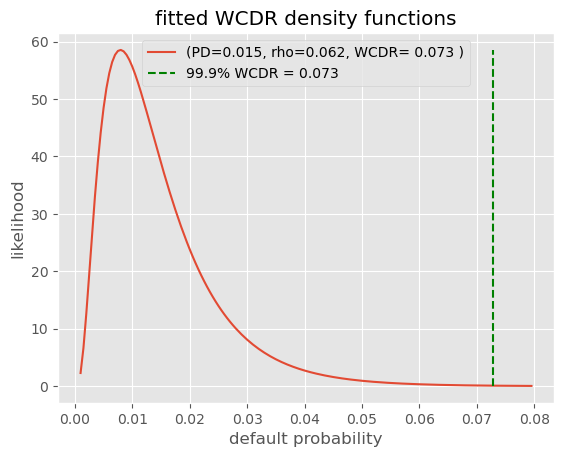

In [25]:
PD_rho_pairs = [(_DR, _rho)]
WCDR_p = .999

dr_set = np.arange(.001,.08,.0005)
for PD1, rho1 in PD_rho_pairs:
    likelihood.PD, likelihood.rho = PD1, rho1
    density = [likelihood.compute_likelihood(dr) for dr in dr_set]
    WCDR = likelihood.WCDR(PD1, rho1, WCDR_p)
    ax = plt.plot(dr_set, density, label=f"(PD={PD1:0.3f}, rho={rho1:0.3f}, WCDR={WCDR: 0.3f} )")
    plt.plot([WCDR] * 2,[min(density), max(density)], '--', color='green', label=f"{WCDR_p * 100}% WCDR = {WCDR:0.3f}")

plt.title("fitted WCDR density functions")
plt.xlabel('default probability')
plt.ylabel('likelihood')
plt.legend()
plt.show()

99.9% worst case default rate =  0.07288


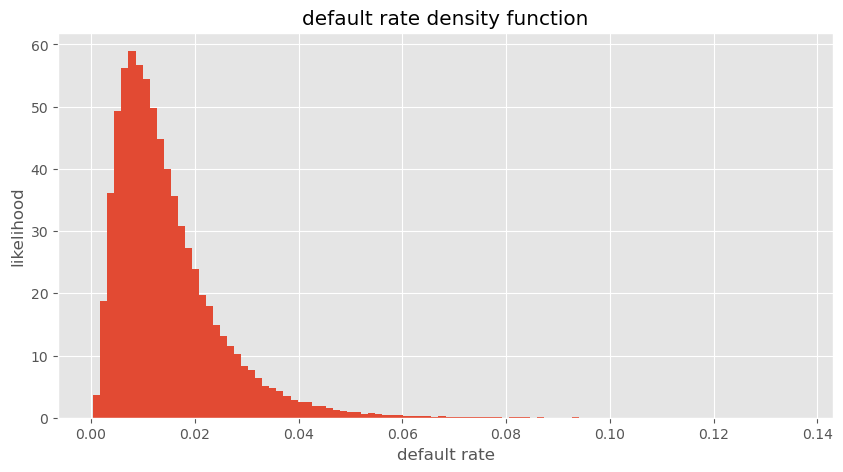

99.9% worst case default rate =  0.07288
99.89% of observations less than WCDR_p = 0.999 value of WCDR = np.float64(0.07288420214133073)


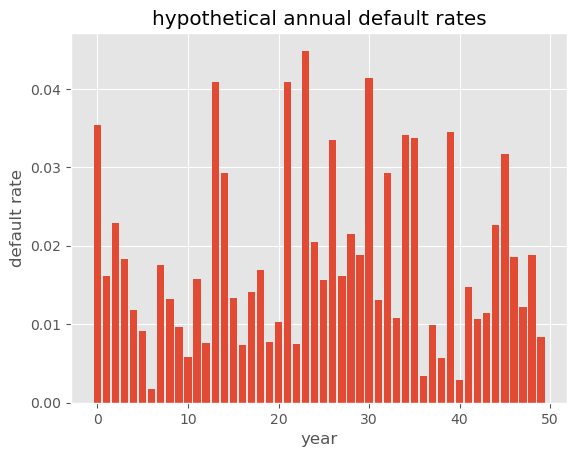

In [26]:
from scipy.stats import norm

from random import random

WCDR_p = .999
WCDR = likelihood.WCDR(PD1, rho1, WCDR_p)
print(f"{WCDR_p * 100}% worst case default rate = {WCDR: 0.5f}")

n_samples = 100000

F = np.random.normal(0, 1, n_samples)
Z = norm.cdf((norm.ppf(PD1) - np.sqrt(rho1) * F) / np.sqrt(1.0 - rho1))

plt.figure(figsize=(10,5))
plt.hist(Z, bins=100, density=True)
plt.title("default rate density function")
plt.xlabel("default rate")
plt.ylabel("likelihood")
plt.show()

WCDR = likelihood.WCDR(PD1, rho1, WCDR_p)
print(f"{WCDR_p * 100}% worst case default rate = {WCDR: 0.5f}")

observed_pct = sum(Z < WCDR) / len(Z) * 100
print(f"{observed_pct:0.2f}% of observations less than {WCDR_p = } value of {WCDR = }")

plt.bar(x=range(50),height=Z[100:150])
plt.title("hypothetical annual default rates")
plt.xlabel("year")
plt.ylabel("default rate")
plt.show()

# Other potential density functions

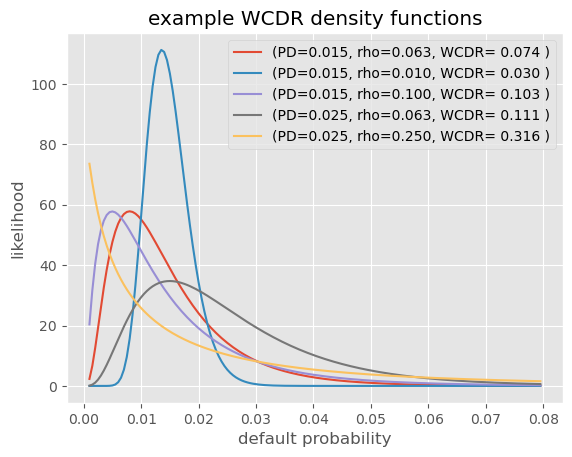

In [27]:

PD_rho_pairs = [(.0148,.063),(.0148,.010),(.0148,.100),(.025,.063),(.025,.25)]
WCDR_p = .999

dr_set = np.arange(.001,.08,.0005)
for PD1, rho1 in PD_rho_pairs:
    likelihood.PD, likelihood.rho = PD1, rho1
    density = [likelihood.compute_likelihood(dr) for dr in dr_set]
    WCDR = likelihood.WCDR(PD1, rho1, WCDR_p)
    ax = plt.plot(dr_set, density, label=f"(PD={PD1:0.3f}, rho={rho1:0.3f}, WCDR={WCDR: 0.3f} )") 
    
plt.title("example WCDR density functions")
plt.xlabel('default probability')
plt.ylabel('likelihood')
plt.legend()
plt.show()